# Part 1 - Data Preparation

**Loading the Data**

In [1]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Exploring the Data**

In [2]:
print("======Dataset Shape======")
print(df.shape)
print()
print("======Column Names======")
print(df.columns.tolist())
print()
print("======Dataset Shape======")
print(df.shape)
print()
print("======Data Types======")
print(df.dtypes)
print()
print("======Missing Values======")
print(df.isnull().sum())
print()
print("======Total Missing Values", df.isnull().sum().sum())

======Dataset Shape======
(768, 9)

======Column Names======
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

======Dataset Shape======
(768, 9)

======Data Types======
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

======Missing Values======
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

======Total Missing Values 0


**Data Cleanup - Identifying values that are medically impossible**

Eg: A person cannot have 0 values for Glucose, BMI, BloodPressure etc...

In [3]:
print("======M======")
print((df == 0).sum())

======M======
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


Treating the medically incorrect values as missing.

In [4]:
import numpy as np
cols_with_invalid_zeroes = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_invalid_zeroes] = df[cols_with_invalid_zeroes].replace(0, np.nan)
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


**Separating Data**

In [5]:
# Dependant columns
x = df.drop('Outcome', axis=1)
# Independant column
y = df['Outcome']
print("======X======")
print(x.shape)
print(x.head())
print()
print("======Y======")
print(y.shape)
print(y.head())

======X======
(768, 8)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

======Y======
(768,)
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


**Splitting Data into Train and Test**

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("======X Train======")
print(x_train.shape)
print(x_train.head())
print()
print("======X Test======")
print(x_test.shape)
print(x_test.head())
print()
print("======Y Train======")
print(y_train.shape)
print(y_train.head())
print()
print("======Y Test======")
print(y_test.shape)
print(y_test.head())

======X Train======
(614, 8)
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
60             2     84.0            NaN            NaN      NaN   NaN   
618            9    112.0           82.0           24.0      NaN  28.2   
346            1    139.0           46.0           19.0     83.0  28.7   
294            0    161.0           50.0            NaN      NaN  21.9   
231            6    134.0           80.0           37.0    370.0  46.2   

     DiabetesPedigreeFunction  Age  
60                      0.304   21  
618                     1.282   50  
346                     0.654   22  
294                     0.254   65  
231                     0.238   46  

======X Test======
(154, 8)
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6     98.0           58.0           33.0    190.0  34.0   
324            2    112.0           75.0           32.0      NaN  35.7   
624            2    108.0           64.0            N

**Imputing on x_train**

In [7]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
x_train[cols_with_invalid_zeroes] = imputer.fit_transform(x_train[cols_with_invalid_zeroes])
print(x_train.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


**Imputing on x_test with learned median from x_train**

In [8]:
x_test[cols_with_invalid_zeroes] = imputer.transform(x_test[cols_with_invalid_zeroes])
print(x_test.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


**Feature Scaling**

In [9]:
# Before scaling
print('======Before Scaling======')
print(x_train.describe().loc[['min', 'max']])
print(x_train.agg(['mean', 'std']))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

import pandas as pd
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

# After scaling
print('======After Scaling======')
print(x_train_scaled.describe().loc[['min', 'max']])
print(x_train_scaled.agg(['mean', 'std']))

======Before Scaling======
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
min          0.0     44.0           24.0            8.0     14.0  18.2   
max         17.0    199.0          122.0           63.0    846.0  67.1   

     DiabetesPedigreeFunction   Age  
min                     0.078  21.0  
max                     2.420  81.0  
      Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
mean     3.742671  121.815961      72.229642      28.568404  138.115635   
std      3.313264   30.104012      12.099278       8.410029   88.650282   

            BMI  DiabetesPedigreeFunction        Age  
mean  32.348208                  0.469168  32.907166  
std    6.935618                  0.336847  11.503437  
======After Scaling======
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
min    -1.130523 -2.587011      -3.989409      -2.447693 -1.401201 -2.041598   
max     4.004552  2.566002       4.116852       4.097449  7

# Part 2 - Building the Artificial Neural Network

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

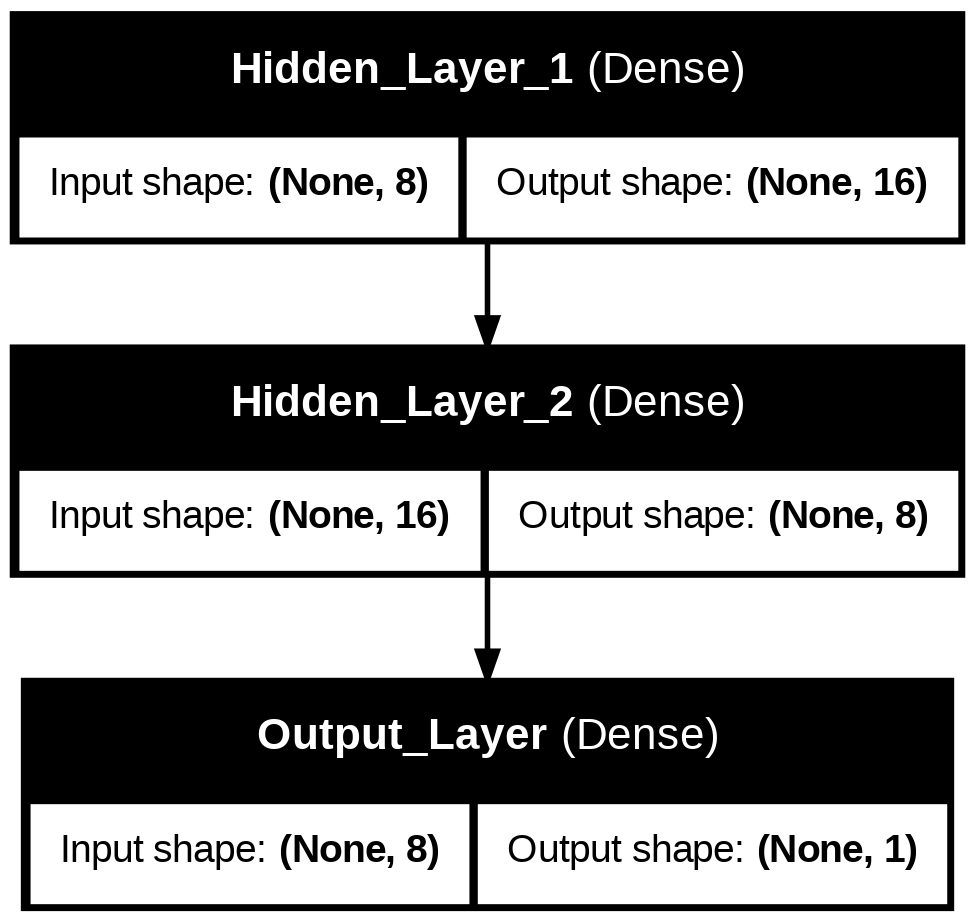

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(x_train_scaled.shape[1],), name='Input_Layer'),
    Dense(16, activation='relu', name='Hidden_Layer_1'),
    Dense(8, activation='relu', name='Hidden_Layer_2'),
    Dense(1, activation='sigmoid', name='Output_Layer')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    to_file='ann_architecture.png'
)

# Part 3 - Model Training

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.3360 - loss: 0.9188 - val_accuracy: 0.3415 - val_loss: 0.8606
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3666 - loss: 0.8281 - val_accuracy: 0.3740 - val_loss: 0.7952
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3931 - loss: 0.7679 - val_accuracy: 0.4146 - val_loss: 0.7514
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4399 - loss: 0.7256 - val_accuracy: 0.4553 - val_loss: 0.7166
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5418 - loss: 0.6924 - val_accuracy: 0.5610 - val_loss: 0.6844
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6558 - loss: 0.6609 - val_accuracy: 0.6829 - val_loss: 0.6570
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7413 - loss: 0.6314 - val_accuracy: 0.6829 - val_loss: 0.6265
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7393 - loss: 0.5987 - val_accuracy: 0.6748 - v

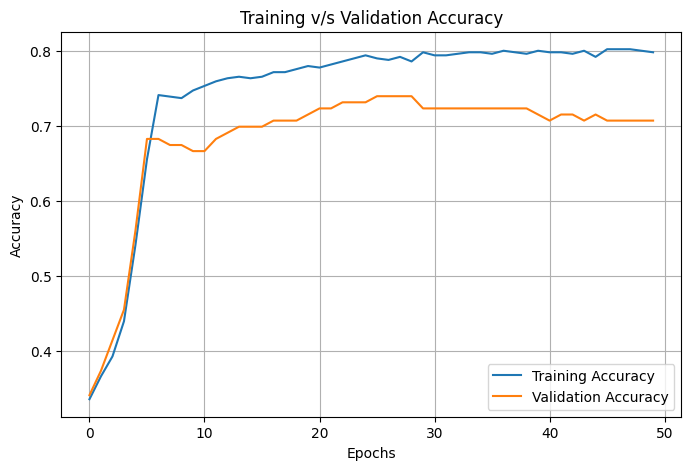

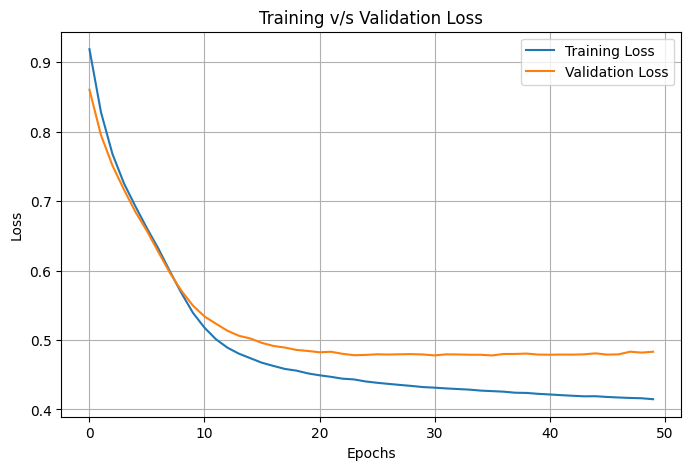

In [11]:
history = model.fit(
    x_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    verbose=1
)
print("Final Training Accuracy:", round(history.history['accuracy'][-1] * 100, 2))
print("Final Validation Accuracy:", round(history.history['val_accuracy'][-1] * 100, 2))
print("Number of Epochs Used:", len(history.history['accuracy']))

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title('Training v/s Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title('Training v/s Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Part 4 - Model Evaluation

In [12]:
y_pred_prob = model.predict(x_test_scaled)
print(y_pred_prob[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[0.31026527]
 [0.06900533]
 [0.04734076]
 [0.15278082]
 [0.47398505]
 [0.49941152]
 [0.00414817]
 [0.52912635]
 [0.6920934 ]
 [0.6612267 ]]


In [13]:
y_pred = (y_pred_prob > 0.5).astype(int)
print(y_pred[:10])

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]]


In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("======Accuracy Score======")
print(round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print("======Confusion Matrix======")
print(confusion_matrix(y_test, y_pred))
print()
print("======Classification Report======")
print(classification_report(y_test, y_pred))

======Accuracy Score======
78.57 %

======Confusion Matrix======
[[84 15]
 [18 37]]

======Classification Report======
              precision    recall  f1-score   support

           0       0.82      0.85      0.84        99
           1       0.71      0.67      0.69        55

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.78      0.79      0.78       154



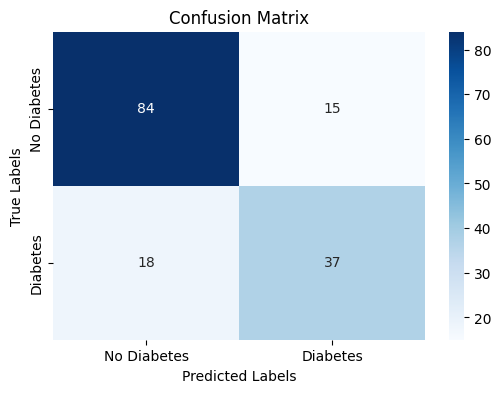

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

*Interpretation*: The ANN achieved a test accuracy of 78.57% on the diabetes dataset. From the confusion matrix, the model correctly identified 84 non-diabetic patients and 37 diabetic patients. However, it misclassified 15 non-diabetic patients as diabetic (False Positives) and failed to identify 18 diabetic patients (False Negatives).